### Sentiment analysis

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import re
import string
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression

In [2]:
df=pd.read_csv('review.csv',encoding='latin-1',names=["target","ids","date","flag","user","text"])

In [3]:
df['target']=df['target'].replace(4, 1)

In [4]:
df_pos=df[df['target']==1].sample(25000, random_state=42)
df_neg=df[df['target']==0].sample(25000, random_state=42)
df_sampled=pd.concat([df_pos, df_neg]).sample(frac=1,random_state=42).reset_index(drop=True)

In [5]:
def clean_tweet(text):
    text=str(text)
    text=re.sub(r'@[A-Za-z0-9_]+', '',text)
    text=re.sub(r'https?://\S+', '',text)
    text=re.sub(r'#', '',text)
    text=''.join([char for char in text if char not in string.punctuation])
    return text.lower().strip()
df_sampled['cleaned_text']=df_sampled['text'].apply(clean_tweet)

In [6]:
vectorizer = CountVectorizer(max_features=25000)
X=vectorizer.fit_transform(df_sampled['cleaned_text'])
y = df_sampled['target']

In [7]:
X

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 538062 stored elements and shape (50000, 25000)>

In [8]:
y

0        0
1        1
2        1
3        1
4        0
        ..
49995    1
49996    0
49997    0
49998    1
49999    1
Name: target, Length: 50000, dtype: int64

In [9]:
X_train,X_test,y_train,y_test=train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

In [10]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 430076 stored elements and shape (40000, 25000)>

In [11]:
X_test

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 107986 stored elements and shape (10000, 25000)>

In [12]:
y_train

47870    1
20387    0
42966    0
19713    0
13853    0
        ..
31197    1
23035    0
47471    0
35451    0
27306    0
Name: target, Length: 40000, dtype: int64

In [13]:
y_test

19183    0
39650    0
30527    1
42235    0
33378    0
        ..
3623     0
47848    0
16331    0
48368    1
4496     0
Name: target, Length: 10000, dtype: int64

In [14]:
NBC_model=MultinomialNB()
NBC_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [15]:
LR_model=LogisticRegression(max_iter=1000)
LR_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


<Axes: >

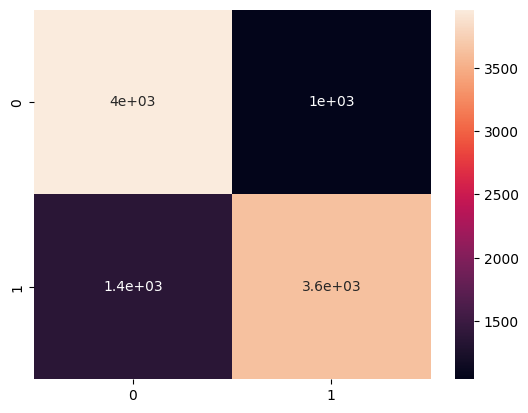

In [16]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred_nb=NBC_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm, annot=True) 

<Axes: >

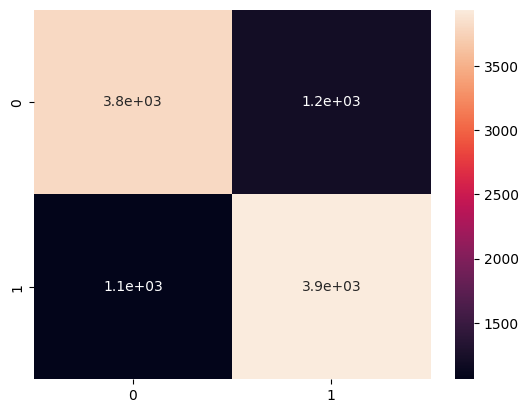

In [17]:
from sklearn.metrics import classification_report,confusion_matrix
ypredict_lr=LR_model.predict(X_test)
cm_lr=confusion_matrix(y_test,ypredict_lr)
sns.heatmap(cm_lr,annot=True)

In [18]:
with open('vectorizer.pkl','wb') as f:
    pickle.dump(vectorizer,f)
with open('naive_bayes_model.pkl','wb') as f:
    pickle.dump(NBC_model,f)
with open('logistic_model.pkl','wb') as f:
    pickle.dump(LR_model, f)